In [1]:
import os
import pandas as pd
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
from wrf import getvar, interplevel, to_np, get_cartopy, latlon_coords
from datetime import datetime
import glob
from netCDF4 import Dataset
import sys
sys.path.insert(1, '/glade/work/ihtam/wrf-stuff/analysis/')
from util.wrf_process import (calc_derive, object_tracking, read_and_write)
from util.ml_preprocess import data_preproc
import gc
from tqdm import tqdm
import xarray as xr
import sys
import pickle
from natsort import natsorted
import proplot as plot
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np, get_cartopy, latlon_coords
from proc_vars import get_precip_class, area_stats
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Nimbus Roman', 'Times', 'C059-Roman', 'P052-Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

def open_pickle(filename):
    with open(filename, "rb") as f:
        loaded_object = pickle.load(f)
    return loaded_object

/glade/derecho/scratch/ihtam/tmp/ipykernel_19539/401654811.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Track path
track_memb03 = xr.open_dataset('/glade/derecho/scratch/ihtam/temp/memb09/track_avor_850-600.nc')
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/temp/memb09/wrfout_d02_2013-11-0*"))[1:28]
dd_p2f_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/memb09_add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:27]
#dd_p2f_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/memb07_add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

In [4]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 9,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_19539/1532609950.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [5]:
def calc_surfvert(ncfile):
    return np.sqrt(getvar(ncfile,'ua')[0,...]**2+getvar(ncfile,'va')[0,...]**2)

def calc_twovort(ncfile,h1,h2):
    # Read in AVOR
    ctrl_avo = getvar(ncfile,'avo')
    # Read in Height
    ctrl_z = getvar(ncfile,'height_agl')
    # Interpolate AVOR to Height level
    ctrl_ht_a = interplevel(ctrl_avo, ctrl_z, h1)
    ctrl_ht_b = interplevel(ctrl_avo, ctrl_z, h2)
    return ctrl_ht_a, ctrl_ht_b

def calc_precipclass(ncfile,ix,iy,ra):
    # Get Precip Class
    ctrl_pclass = get_precip_class(ncfile)[int(iy)-ra:int(iy)+ra,int(ix)-ra:int(ix)+ra]
    # Derive axisymmetry
    ctrl_pclasses = {'conv':area_stats(np.sum(ctrl_pclass==1), 4*ra*ra), 'strat':area_stats(np.sum(ctrl_pclass==4), 4*ra*ra),
                     'cong':area_stats(np.sum(ctrl_pclass==2),4*ra*ra), 'shal':area_stats(np.sum(ctrl_pclass==3),4*ra*ra),
                     'anvil':area_stats(np.sum(ctrl_pclass==5),4*ra*ra)}
    return ctrl_pclasses

In [6]:
def proc_onevar_loop(fileslist,track,dr,TYPE):
    varouts = []
    for i in tqdm(range(len(fileslist))):
        nc_ctrl = Dataset(fileslist[i])
        # Target location
        target_lat = track_memb03['clat'][12+1+i]
        target_lon = track_memb03['clon'][12+1+i]
        # Compute track indices
        ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
        if TYPE=='slp':
            ctrl_slp = getvar(nc_ctrl,'slp')
            varouts.append(float(ctrl_slp[int(iy)-dr:int(iy)+dr,int(ix)-dr:int(ix)+dr].min()))
            del ctrl_slp
            gc.collect()
        elif TYPE=='vmax':
            ctrl_slp = calc_surfvert(nc_ctrl)
            varouts.append(float(ctrl_slp[int(iy)-dr:int(iy)+dr,int(ix)-dr:int(ix)+dr].max()))
            del ctrl_slp
            gc.collect()
        elif TYPE=='vorts':
            h1 = 1000
            h2 = 6000
            ctrl_slp_a, ctrl_slp_b = calc_twovort(nc_ctrl,h1,h2)
            dicts = {
                h1:float(ctrl_slp_a[int(iy)-dr:int(iy)+dr,int(ix)-dr:int(ix)+dr].mean()),
                h2:float(ctrl_slp_b[int(iy)-dr:int(iy)+dr,int(ix)-dr:int(ix)+dr].mean())
            }     
            varouts.append(dicts)
            del ctrl_slp_a, ctrl_slp_b, dicts
            gc.collect()
        elif TYPE=='pclasses':
            varouts.append(calc_precipclass(fileslist[i],ix,iy,dr))
    return varouts

In [7]:
ctrl_mslp = proc_onevar_loop(ctrl_files,track_memb03,50,'slp')
dd_p2f_mslp = proc_onevar_loop(dd_p2f_files,track_memb03,50,'slp')
#mdd_p2f_mslp = proc_onevar_loop(mdd_p2f_files,track_memb03,50,'slp')

100%|██████████| 27/27 [02:11<00:00,  4.87s/it]


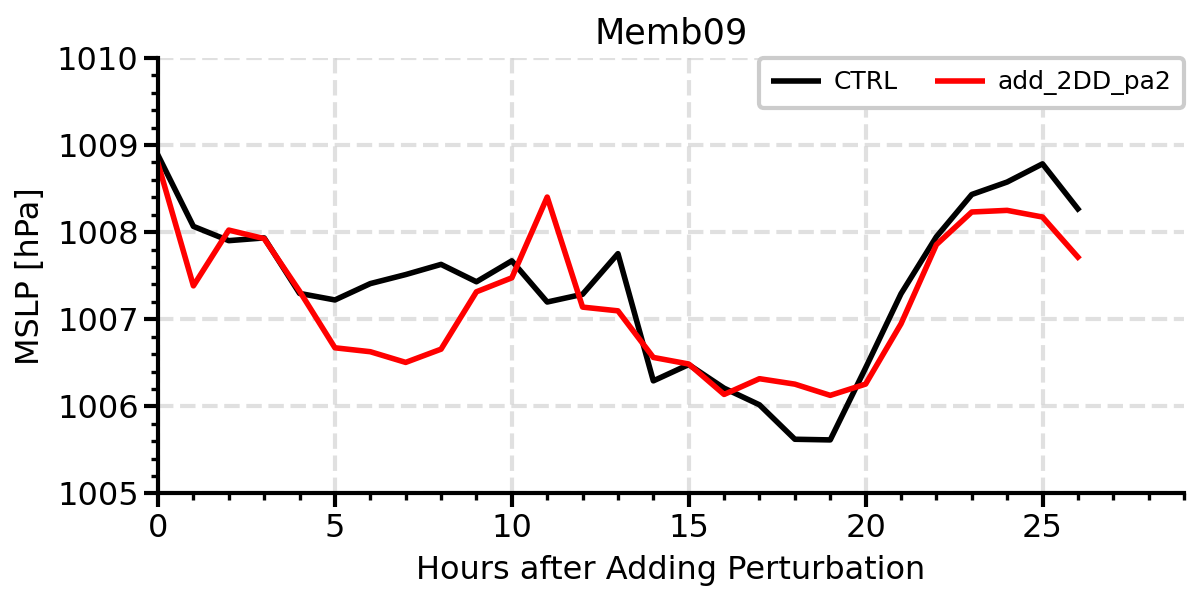

In [10]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(ctrl_mslp,c='k',label='CTRL',lw=2)
#axs.plot(mdd_p2f_mslp,c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(dd_p2f_mslp,c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.format(xlim=(0,29),ylim=(1005,1010),
           xlabel='Hours after Adding Perturbation', ylabel='MSLP [hPa]', title='Memb09')
plt.legend(loc=1,ncols=2)
plt.savefig('./pics/mslp_wrfsens_memb09.png',dpi=400)
plt.show()

In [11]:
ctrl_vmax = proc_onevar_loop(ctrl_files,track_memb03,50,'vmax')
dd_p2f_vmax = proc_onevar_loop(dd_p2f_files,track_memb03,50,'vmax')
#mdd_p2f_vmax = proc_onevar_loop(mdd_p2f_files,track_memb03,50,'vmax')

100%|██████████| 27/27 [01:57<00:00,  4.34s/it]


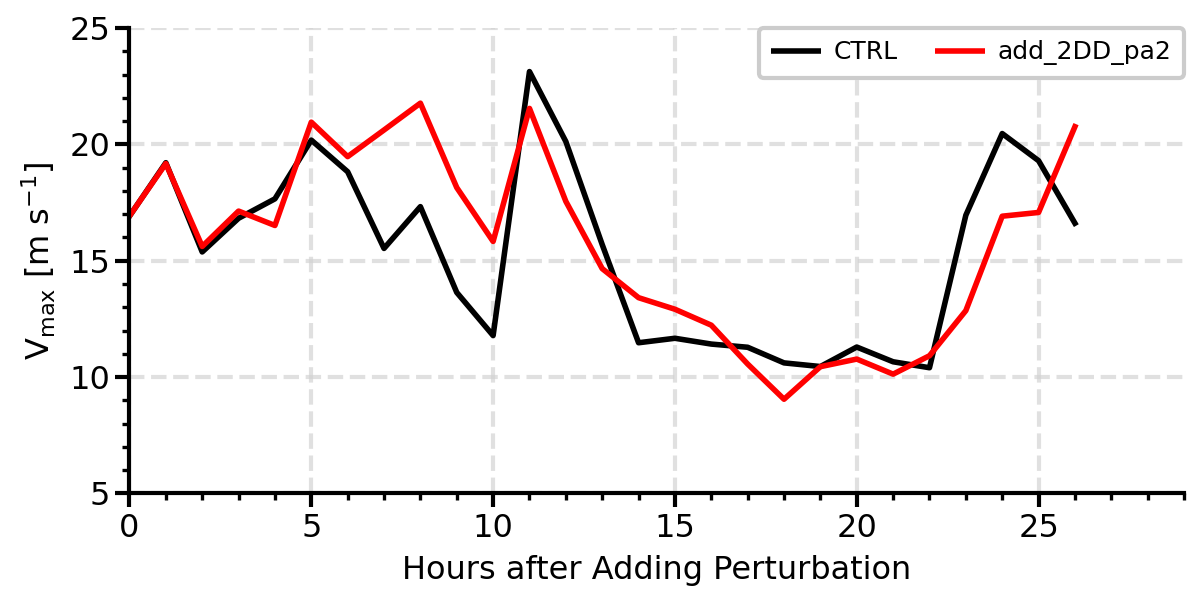

In [15]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(ctrl_vmax,c='k',label='CTRL',lw=2)
#axs.plot(mdd_p2f_vmax,c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.plot(dd_p2f_vmax,c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.format(xlim=(0,29),ylim=(5,25),
           xlabel='Hours after Adding Perturbation', ylabel='V$_{max}$ [m s$^{-1}$]')
plt.legend(loc=1,ncols=2)
plt.savefig('./pics/vmax_wrfsens_memb09.png',dpi=400)
plt.show()

In [13]:
ctrl_vorts = proc_onevar_loop(ctrl_files,track_memb03,100,'vorts')
dd_p2f_vorts = proc_onevar_loop(dd_p2f_files,track_memb03,100,'vorts')
#mdd_p2f_vorts = proc_onevar_loop(mdd_p2f_files,track_memb03,100,'vorts')

100%|██████████| 27/27 [03:20<00:00,  7.41s/it]


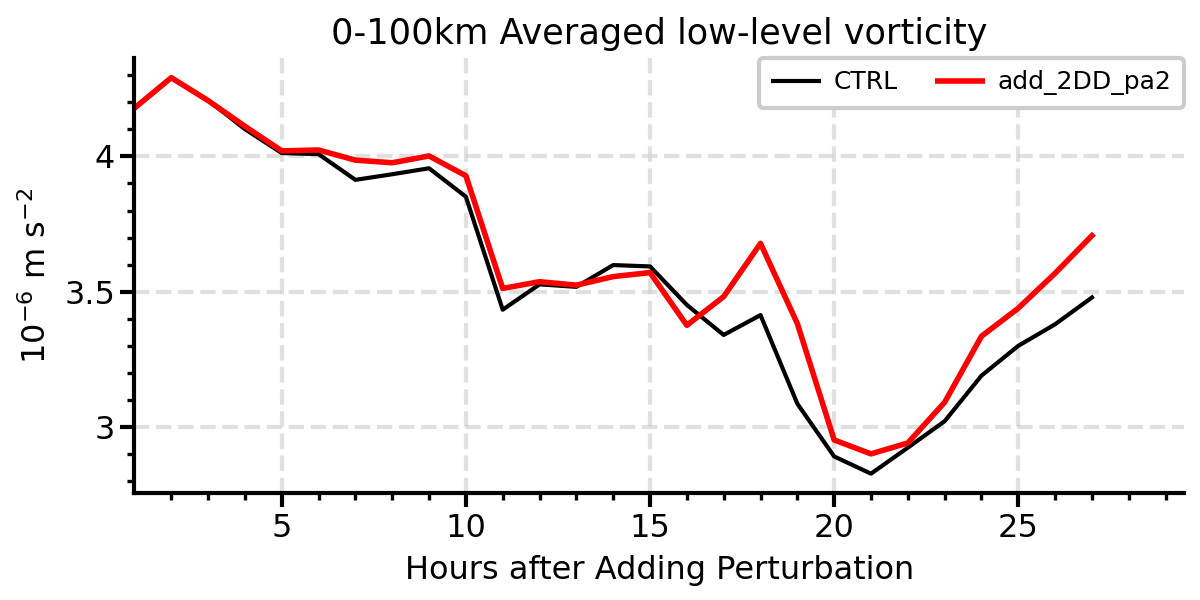

In [16]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,26,27)+1,[obj[1000] for obj in ctrl_vorts],c='k',label='CTRL')
axs.plot(np.linspace(0,26,27)+1,[obj[1000] for obj in dd_p2f_vorts],c='r',ls='-',label='add_2DD_pa2',lw=2)
#axs.plot(np.linspace(0,28,29)+1,[obj[1000] for obj in mdd_p2f_vorts],c='r',ls='--',label='minus_2DD_pa2',lw=2)

axs.format(xlim=(1,29.5),#ylim=(0,1),
           title='0-100km Averaged low-level vorticity',
           xlabel='Hours after Adding Perturbation', ylabel='10$^{-6}$ m s$^{-2}$')
plt.legend(loc=1,ncols=2)
plt.savefig('./pics/avo1km_memb09.png',dpi=400)
plt.show()

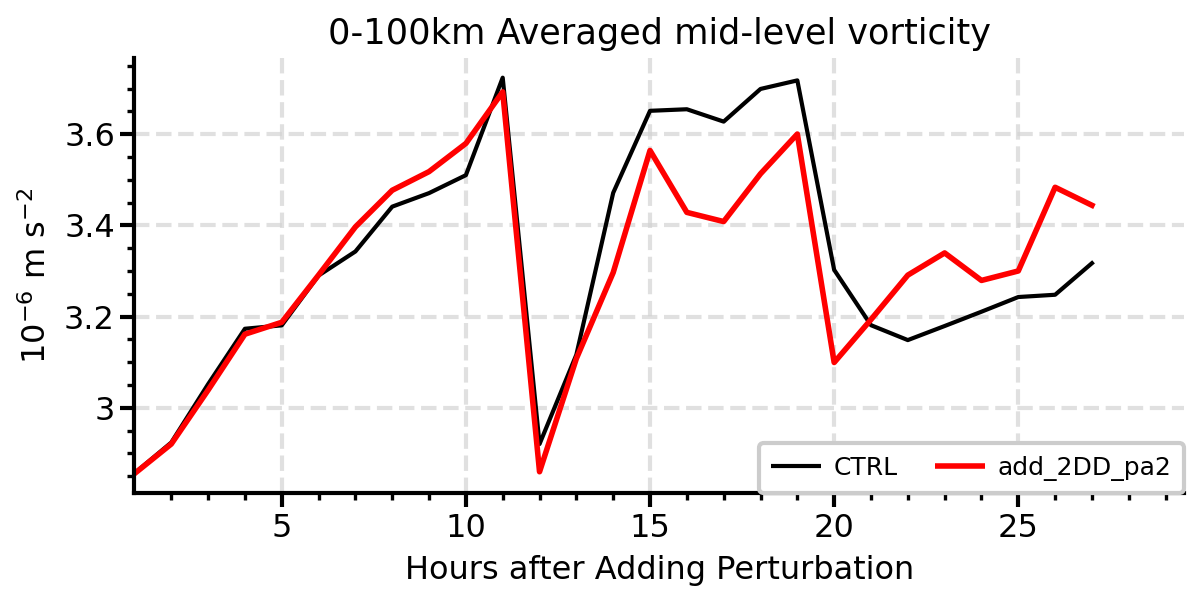

In [17]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,26,27)+1,[obj[6000] for obj in ctrl_vorts],c='k',label='CTRL')
axs.plot(np.linspace(0,26,27)+1,[obj[6000] for obj in dd_p2f_vorts],c='r',ls='-',label='add_2DD_pa2',lw=2)
#axs.plot(np.linspace(0,28,29)+1,[obj[6000] for obj in mdd_p2f_vorts],c='r',ls='--',label='minus_2DD_pa2',lw=2)

axs.format(xlim=(1,29.5),#ylim=(0,1),
           title='0-100km Averaged mid-level vorticity',
           xlabel='Hours after Adding Perturbation', ylabel='10$^{-6}$ m s$^{-2}$')
plt.legend(loc=1,ncols=2)
plt.savefig('./pics/avo6km_memb09.png',dpi=400)
plt.show()

In [ ]:
ctrl_pclasses = proc_onevar_loop(ctrl_files,track_memb03,100,'pclasses')
dd_p2f_pclasses = proc_onevar_loop(dd_p2f_files,track_memb03,100,'pclasses')
mdd_p2f_pclasses = proc_onevar_loop(mdd_p2f_files,track_memb03,100,'pclasses')

 83%|████████▎ | 24/29 [02:44<00:31,  6.32s/it]

In [ ]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['conv'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Convective Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/conv_memb07.png',dpi=400)
plt.show()

In [ ]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in ctrl_pclasses],c='k',label='CTRL')
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in dd_p2f_pclasses],c='r',ls='-',label='add_2DD_pa2',lw=2)
axs.plot(np.linspace(0,28,29)+1,[obj['strat'] for obj in mdd_p2f_pclasses],c='r',ls='--',label='minus_2DD_pa2',lw=2)
axs.format(xlim=(1,30.5),#ylim=(0,1),
           title='0-100km Stratiform Fraction',
           xlabel='Hours after Adding Perturbation', ylabel='%')
#plt.legend(loc=1,ncols=2)
plt.savefig('./pics/strat_memb07.png',dpi=400)
plt.show()